# Calculate Methane Concentrations from Time Series Data and Visualize to Identify Significant Events

In [2]:
# Dependencies
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [35]:
methane_df = pd.read_csv('../../MASSPA_2017_Time_Series_Ready.csv')

In [36]:
display(methane_df)

,Timestamp,Mass,Partial_Pressure,Source_File
0,2017-01-01 02:46:24,1.0,2.510000e-08,Jan_01_2017__02-46-24_AM.txt
1,2017-01-01 02:46:24,1.1,3.260000e-08,Jan_01_2017__02-46-24_AM.txt
2,2017-01-01 02:46:24,1.2,6.640000e-08,Jan_01_2017__02-46-24_AM.txt
3,2017-01-01 02:46:24,1.3,1.070000e-07,Jan_01_2017__02-46-24_AM.txt
4,2017-01-01 02:46:24,1.4,1.050000e-07,Jan_01_2017__02-46-24_AM.txt
...,...,...,...,...
29502065,2017-11-07 00:50:58,99.6,3.350000e-10,Nov_07_2017__12-50-58_AM.txt
29502066,2017-11-07 00:50:58,99.7,3.270000e-10,Nov_07_2017__12-50-58_AM.txt
29502067,2017-11-07 00:50:58,99.8,2.540000e-10,Nov_07_2017__12-50-58_AM.txt
29502068,2017-11-07 00:50:58,99.9,3.040000e-10,Nov_07_2017__12-50-58_AM.txt


In [37]:
# How many unique values are there in the 'Timestamp' column?
unique_timestamps = methane_df['Timestamp'].nunique()
print(f'Number of unique timestamps: {unique_timestamps}')

Number of unique timestamps: 29770


In [38]:
# How many unique days are there in the 'Timestamp' column?
methane_df['Date'] = pd.to_datetime(methane_df['Timestamp']).dt.date
unique_days = methane_df['Date'].nunique()
print(f'Number of unique days: {unique_days}')

Number of unique days: 23


In [ ]:
# Make a new dataframe with a row for each unique timestamp
# From the original dataframe, for each row with the same timestamp, 
# sum the 'Partial_Pressure' and save as 'Total_Pressure' in the new dataframe
# From the original dataframe, for each timestamp, 
# pick out the value of 'Partial_Pressure' where the values of 'Mass' = 16, and save as 'Methane_Pressure' in the new dataframe
new_df = methane_df.groupby('Timestamp').agg(
    Total_Pressure=('Partial_Pressure', 'sum'),
    Methane_Pressure=('Partial_Pressure', lambda x: x[methane_df.loc[x.index, 'Mass'] == 16].sum()),
    Hydrogen_Pressure=('Partial_Pressure', lambda x: x[methane_df.loc[x.index, 'Mass'] == 2].sum()),
    Sulfide_Pressure=('Partial_Pressure', lambda x: x[methane_df.loc[x.index, 'Mass'] == 34].sum())
).reset_index()

In [40]:
# Next, we will do some simple aqueous chemistry
# to convert from Methane_Pressure and Total_Pressure to a methane concentration in micromoles per liter (µM)
# We will use Henry's Law, which states that the concentration of a gas in a liquid is proportional to the partial pressure of the gas above the liquid
# The proportionality constant is called the Henry's Law constant, which is 1.4*10^-3 mol/(L*atm) from the NOAA tables
# Then convert using Henry's Law: C = kH * P, where C is the concentration in mol/L, kH is the Henry's Law constant, and P is the partial pressure in atm
henrys_constant_methane = 1.4e-3  # mol/(L*atm)
new_df['Methane_Concentration_uM'] = (new_df['Methane_Pressure'] / new_df['Total_Pressure']) * henrys_constant_methane * 1e6 # Convert from mol/L to μM

# Now we will do the same for Hydrogen, which has a mass of 2.0 and a Henry's Law constant of 7.8*10^-4 mol/(L*atm)
henrys_constant_hydrogen = 7.8e-4  # mol/(L*atm)
new_df['Hydrogen_Concentration_uM'] = (new_df['Hydrogen_Pressure'] / new_df['Total_Pressure']) * henrys_constant_hydrogen * 1e6 # Convert from mol/L to μM

# We will do the same for Hydrogen Sulfide, which has a mass of 34 and a Henry's Law Contant of 1 * 10^-1 mol/(L*atm)

henrys_constant_sulfide = 0.1
new_df['Sulfide_Concentration_mM'] = (new_df['Sulfide_Pressure'] / new_df['Total_Pressure']) * henrys_constant_hydrogen * 1e3 # Convert from mol/L to mM

In [41]:
new_df

,Timestamp,Total_Pressure,Methane_Pressure,Hydrogen_Pressure,Sulfide_Pressure,Methane_Concentration_uM,Hydrogen_Concentration_uM,Sulfide_Concentration_mM
0,2017-01-01 02:46:24,0.001414,1.840000e-06,2.250000e-07,1.690000e-07,1.822143,0.124141,0.000093
1,2017-01-01 02:46:46,0.001347,1.680000e-06,1.710000e-07,1.620000e-07,1.746255,0.099029,0.000094
2,2017-01-01 02:47:08,0.001304,1.630000e-06,1.480000e-07,1.540000e-07,1.749868,0.088521,0.000092
3,2017-01-01 02:47:30,0.001271,1.610000e-06,1.350000e-07,1.500000e-07,1.773497,0.082852,0.000092
4,2017-01-01 02:47:52,0.001250,1.570000e-06,1.230000e-07,1.450000e-07,1.757702,0.076722,0.000090
...,...,...,...,...,...,...,...,...
29765,2017-11-07 00:49:29,0.000007,1.130000e-08,9.350000e-08,1.240000e-10,2.361749,10.887634,0.000014
29766,2017-11-07 00:49:51,0.000007,1.160000e-08,9.250000e-08,6.290000e-11,2.476919,11.004293,0.000007
29767,2017-11-07 00:50:13,0.000007,1.130000e-08,9.220000e-08,2.770000e-10,2.387645,10.853973,0.000033
29768,2017-11-07 00:50:36,0.000006,1.120000e-08,9.040000e-08,1.730000e-11,2.412778,10.850114,0.000002


In [42]:
# Find the maximum of the 'Methane_Concentration_uM' column
max_methane_concentration = new_df['Methane_Concentration_uM'].max()
print(f'Maximum methane concentration: {max_methane_concentration} uM')

# And the minimum
min_methane_concentration = new_df['Methane_Concentration_uM'].min()
print(f'Minimum methane concentration: {min_methane_concentration} uM')
# And the average
average_methane_concentration = new_df['Methane_Concentration_uM'].mean()
print(f'Average methane concentration: {average_methane_concentration} uM')
print()

# And the same for Hydrogen
max_hydrogen_concentration = new_df['Hydrogen_Concentration_uM'].max()
print(f'Maximum hydrogen concentration: {max_hydrogen_concentration} uM')
min_hydrogen_concentration = new_df['Hydrogen_Concentration_uM'].min()
print(f'Minimum hydrogen concentration: {min_hydrogen_concentration} uM')
average_hydrogen_concentration = new_df['Hydrogen_Concentration_uM'].mean()
print(f'Average hydrogen concentration: {average_hydrogen_concentration} uM')
print()

# Add the same for Hydrogen Sulfide
max_sulfide_concentration = new_df['Sulfide_Concentration_mM'].max()
print(f'Maximum hydrogen sulfide concentration: {max_sulfide_concentration} mM')
min_sulfide_concentration = new_df['Sulfide_Concentration_mM'].min()
print(f'Minimum hydrogen sulfide concentration: {min_sulfide_concentration} mM')
average_sulfide_concentration = new_df['Sulfide_Concentration_mM'].mean()
print(f'Average hydrogen sulfide concentration: {average_sulfide_concentration} mM')


Maximum methane concentration: 10.918718375216514 uM
Minimum methane concentration: 0.05344965909303657 uM
Average methane concentration: 2.0624232006546017 uM

Maximum hydrogen concentration: 40.32213741936797 uM
Minimum hydrogen concentration: 0.023160455788830126 uM
Average hydrogen concentration: 4.7094947967875775 uM

Maximum hydrogen sulfide concentration: 0.004686622022187855 mM
Minimum hydrogen sulfide concentration: -0.00012237428879974632 mM
Average hydrogen sulfide concentration: 5.456631969284129e-05 mM


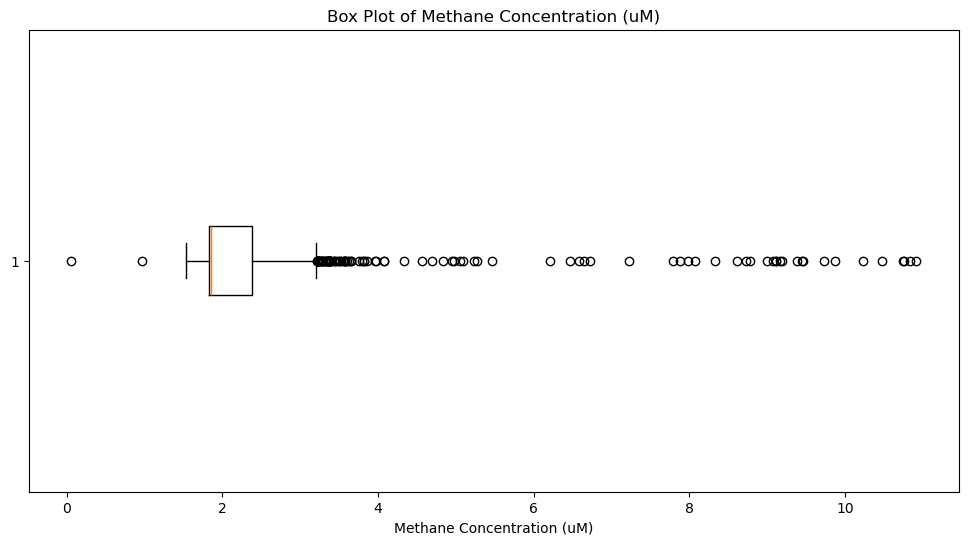

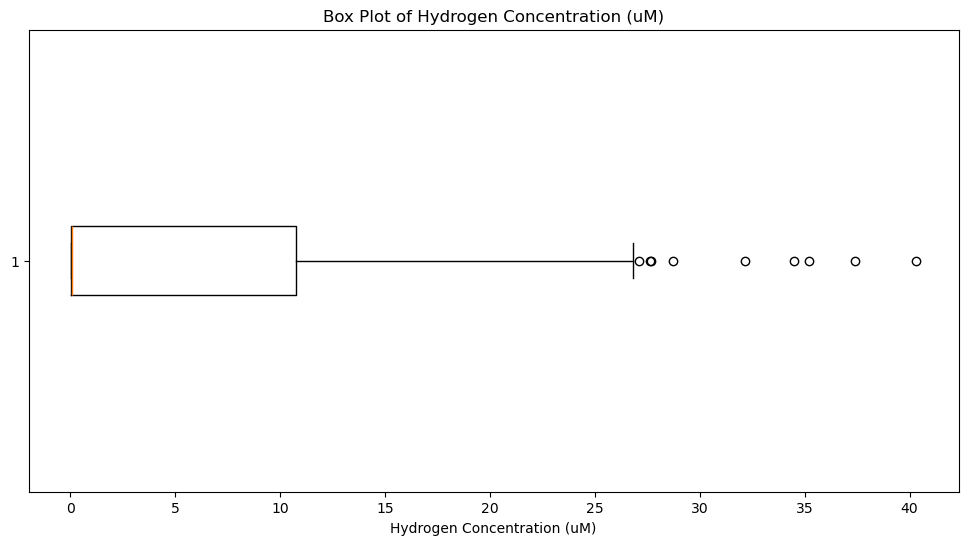

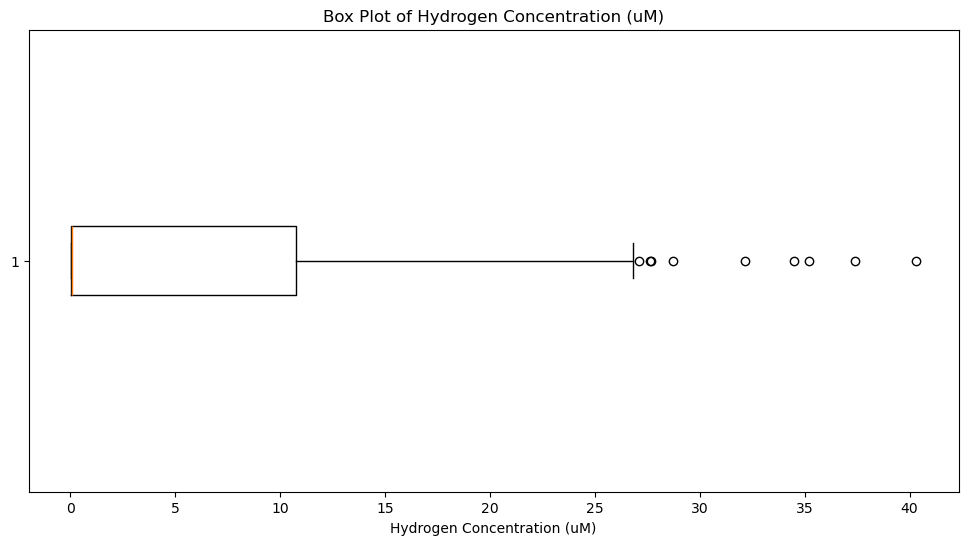

In [43]:
# Box plot of Timestamp vs. Methane_Concentration_um
plt.figure(figsize=(12, 6))
plt.boxplot(new_df['Methane_Concentration_uM'], vert=False)
plt.title('Box Plot of Methane Concentration (uM)')
plt.xlabel('Methane Concentration (uM)')
plt.show()

# And same for Hydrogen
plt.figure(figsize=(12, 6))
plt.boxplot(new_df['Hydrogen_Concentration_uM'], vert=False)
plt.title('Box Plot of Hydrogen Concentration (uM)')
plt.xlabel('Hydrogen Concentration (uM)')
plt.show()

# And same for Hydrogen
plt.figure(figsize=(12, 6))
plt.boxplot(new_df['Hydrogen_Concentration_uM'], vert=False)
plt.title('Box Plot of Hydrogen Concentration (uM)')
plt.xlabel('Hydrogen Concentration (uM)')
plt.show()

In [44]:
# Add new column extracting useful date and time from Timestamp for plotting
new_df['Date'] = pd.to_datetime(new_df['Timestamp']).dt.date
new_df['Time'] = pd.to_datetime(new_df['Timestamp']).dt.time

In [45]:
new_df

,Timestamp,Total_Pressure,Methane_Pressure,Hydrogen_Pressure,Sulfide_Pressure,Methane_Concentration_uM,Hydrogen_Concentration_uM,Sulfide_Concentration_mM,Date,Time
0,2017-01-01 02:46:24,0.001414,1.840000e-06,2.250000e-07,1.690000e-07,1.822143,0.124141,0.000093,2017-01-01,02:46:24
1,2017-01-01 02:46:46,0.001347,1.680000e-06,1.710000e-07,1.620000e-07,1.746255,0.099029,0.000094,2017-01-01,02:46:46
2,2017-01-01 02:47:08,0.001304,1.630000e-06,1.480000e-07,1.540000e-07,1.749868,0.088521,0.000092,2017-01-01,02:47:08
3,2017-01-01 02:47:30,0.001271,1.610000e-06,1.350000e-07,1.500000e-07,1.773497,0.082852,0.000092,2017-01-01,02:47:30
4,2017-01-01 02:47:52,0.001250,1.570000e-06,1.230000e-07,1.450000e-07,1.757702,0.076722,0.000090,2017-01-01,02:47:52
...,...,...,...,...,...,...,...,...,...,...
29765,2017-11-07 00:49:29,0.000007,1.130000e-08,9.350000e-08,1.240000e-10,2.361749,10.887634,0.000014,2017-11-07,00:49:29
29766,2017-11-07 00:49:51,0.000007,1.160000e-08,9.250000e-08,6.290000e-11,2.476919,11.004293,0.000007,2017-11-07,00:49:51
29767,2017-11-07 00:50:13,0.000007,1.130000e-08,9.220000e-08,2.770000e-10,2.387645,10.853973,0.000033,2017-11-07,00:50:13
29768,2017-11-07 00:50:36,0.000006,1.120000e-08,9.040000e-08,1.730000e-11,2.412778,10.850114,0.000002,2017-11-07,00:50:36


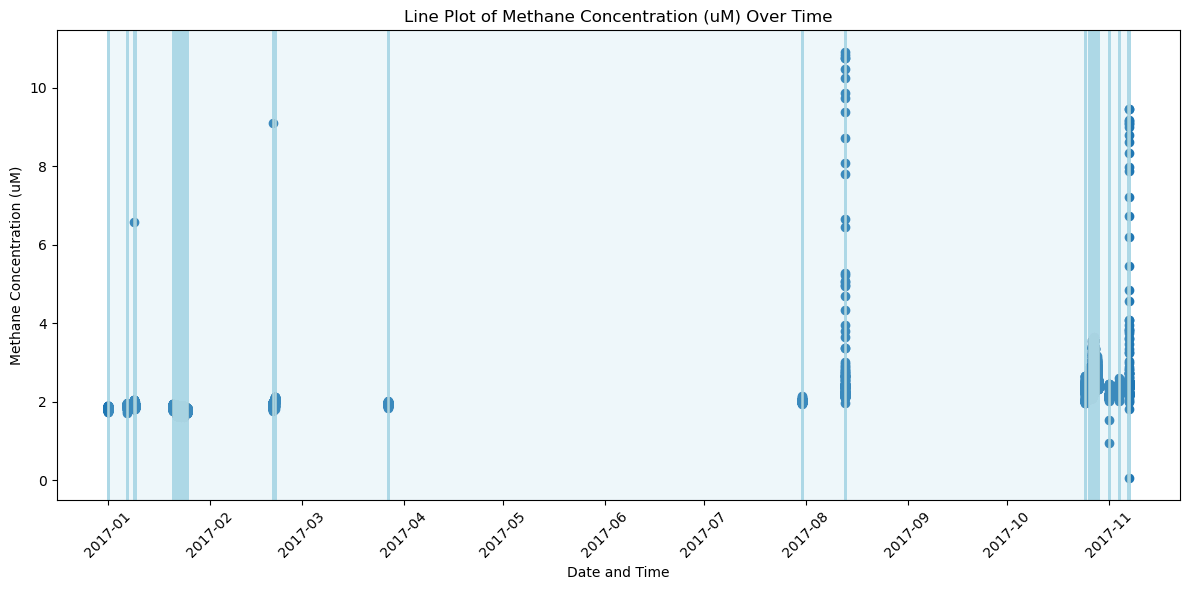

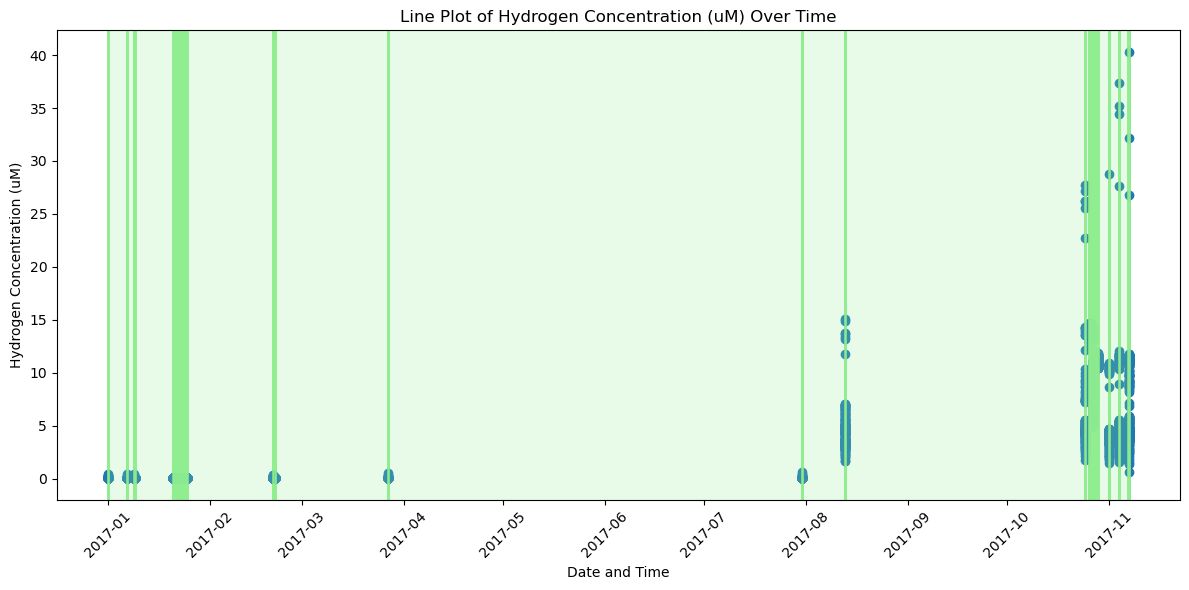

In [22]:
# Plot line plot of Date + Time vs. Methane_Concentration_um, then repeat for Hydrogen
plt.figure(figsize=(12, 6))

# Create a proper datetime column for plotting
new_df['DateTime'] = pd.to_datetime(new_df['Timestamp'])

plt.scatter(new_df['DateTime'], new_df['Methane_Concentration_uM'])

# Add transparent windows highlighting regions for which we have data
for i in range(len(new_df) - 1):
    if new_df.iloc[i]['Methane_Concentration_uM'] > 0 and new_df.iloc[i+1]['Methane_Concentration_uM'] > 0:
        plt.axvspan(new_df.iloc[i]['DateTime'], 
                    new_df.iloc[i+1]['DateTime'], 
                    alpha=0.2, color='lightblue')

plt.title('Line Plot of Methane Concentration (uM) Over Time')
plt.xlabel('Date and Time')
plt.ylabel('Methane Concentration (uM)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Repeat for Hydrogen
plt.figure(figsize=(12, 6))
plt.scatter(new_df['DateTime'], new_df['Hydrogen_Concentration_uM'])

# Add transparent windows highlighting regions for which we have data
for i in range(len(new_df) - 1):
    if new_df.iloc[i]['Hydrogen_Concentration_uM'] > 0 and new_df.iloc[i+1]['Hydrogen_Concentration_uM'] > 0:
        plt.axvspan(new_df.iloc[i]['DateTime'], 
                    new_df.iloc[i+1]['DateTime'], 
                    alpha=0.2, color='lightgreen')

plt.title('Line Plot of Hydrogen Concentration (uM) Over Time')
plt.xlabel('Date and Time')
plt.ylabel('Hydrogen Concentration (uM)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()




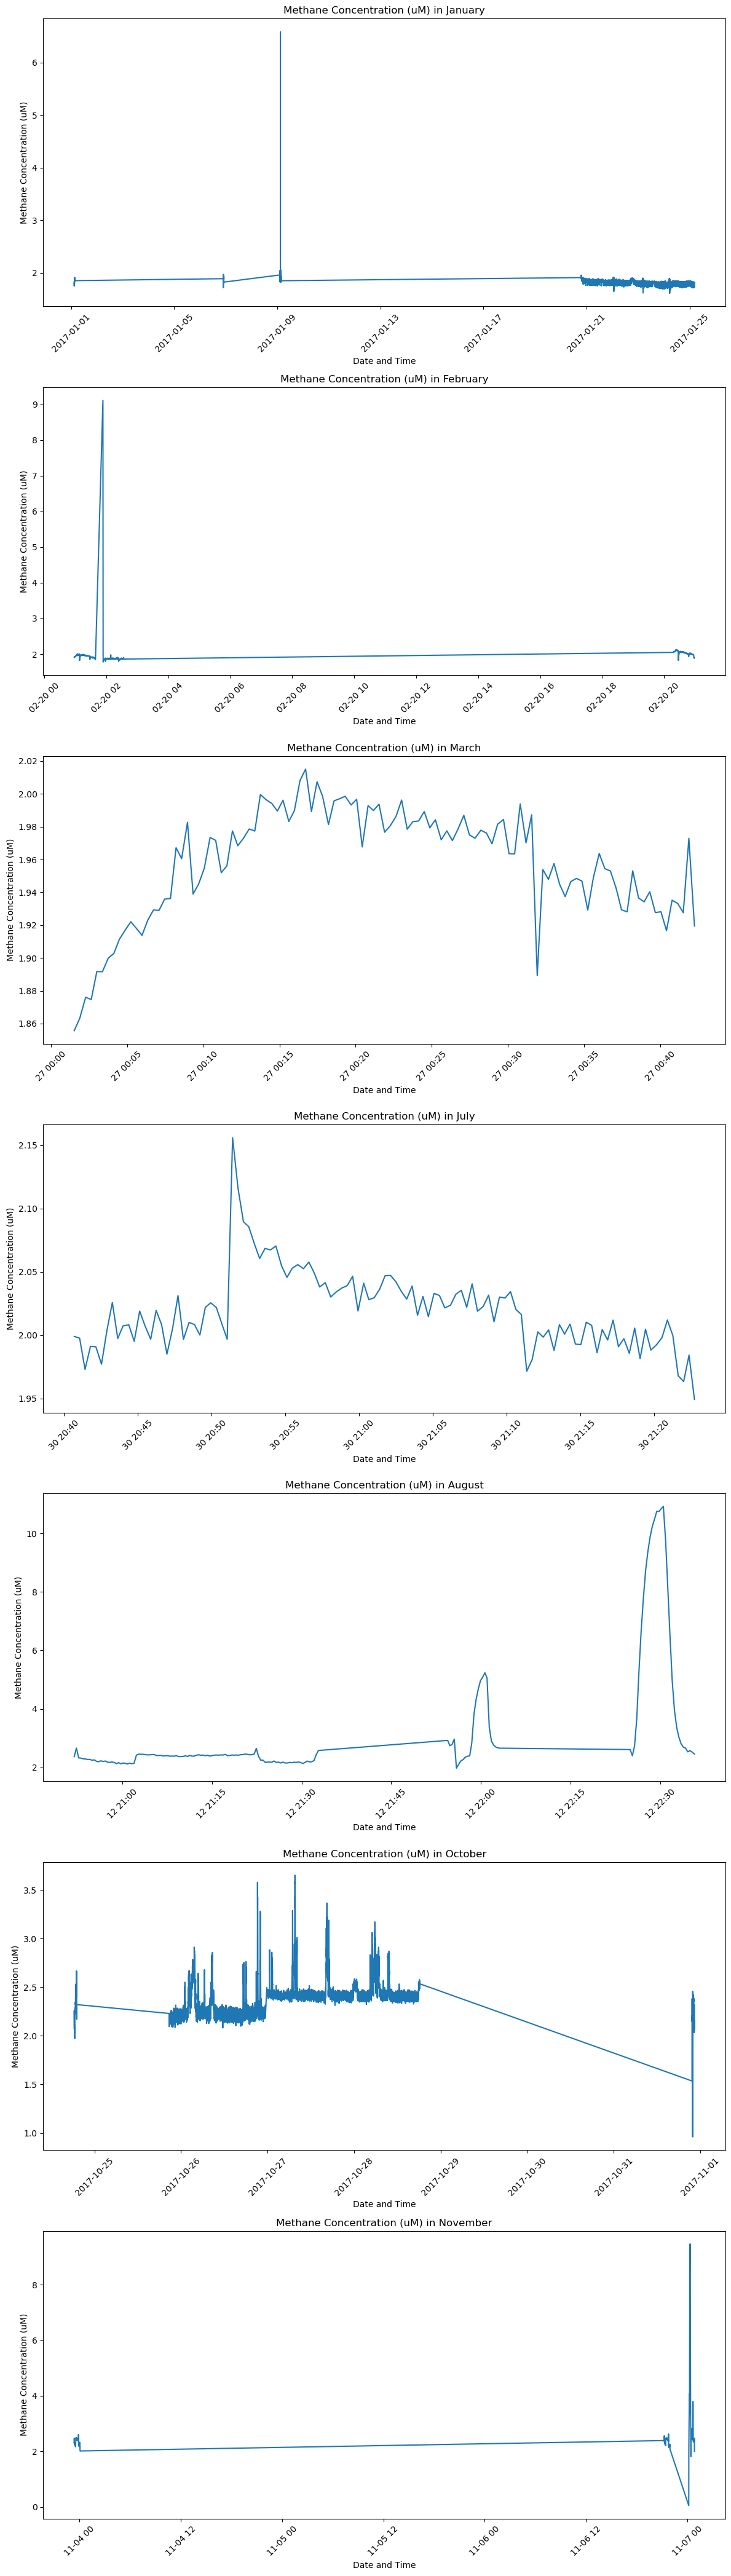

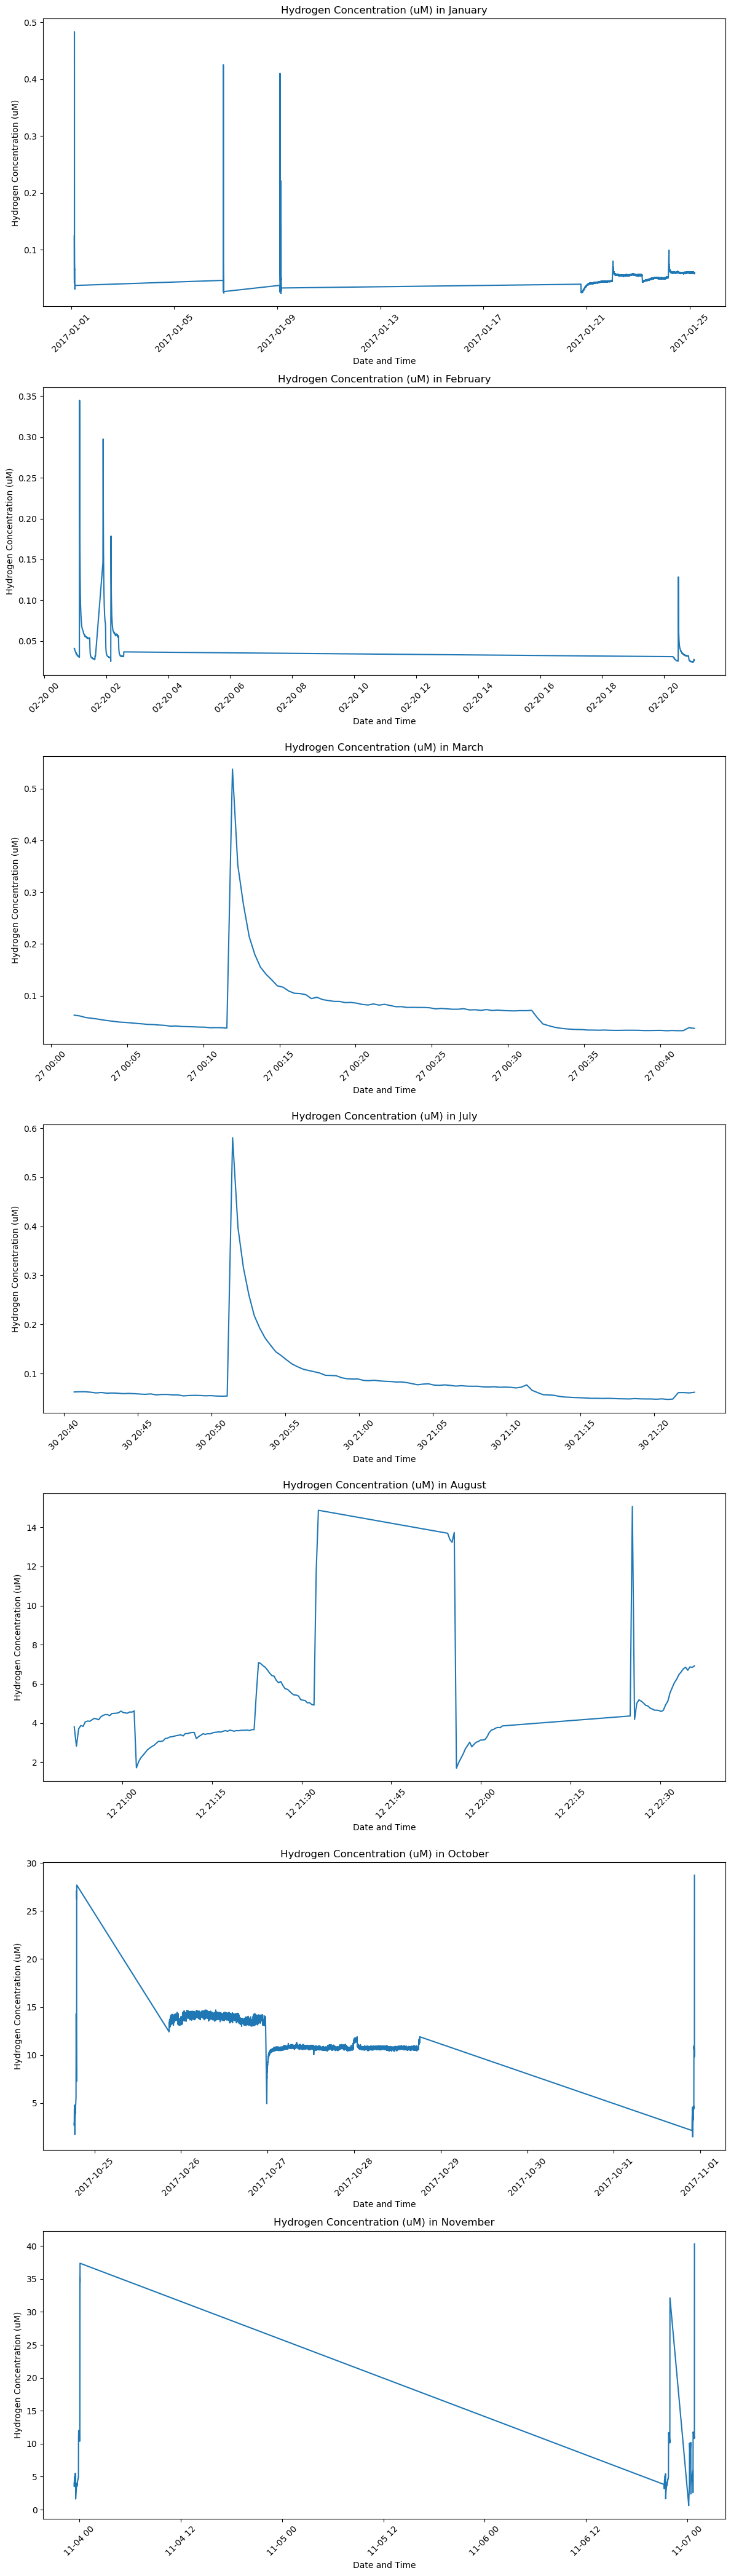

In [23]:
# Plot each month for which we have data on a separate subplot line plot like above
months = new_df['DateTime'].dt.month.unique()
months.sort()
num_months = len(months)
fig, axes = plt.subplots(num_months, 1, figsize=(12, 6*num_months))
for i, month in enumerate(months):
    # Convert month number to month name for title
    month_name = pd.to_datetime(str(month), format='%m').strftime('%B')
    month_data = new_df[new_df['DateTime'].dt.month == month]
    axes[i].plot(month_data['DateTime'], month_data['Methane_Concentration_uM'])
    axes[i].set_title(f'Methane Concentration (uM) in {month_name}')
    axes[i].set_xlabel('Date and Time')
    axes[i].set_ylabel('Methane Concentration (uM)')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# Repeat for Hydrogen
fig, axes = plt.subplots(num_months, 1, figsize=(12, 6*num_months))
for i, month in enumerate(months):
    # Convert month number to month name for title
    month_name = pd.to_datetime(str(month), format='%m').strftime('%B')
    month_data = new_df[new_df['DateTime'].dt.month == month]
    axes[i].plot(month_data['DateTime'], month_data['Hydrogen_Concentration_uM'])
    axes[i].set_title(f'Hydrogen Concentration (uM) in {month_name}')
    axes[i].set_xlabel('Date and Time')
    axes[i].set_ylabel('Hydrogen Concentration (uM)')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

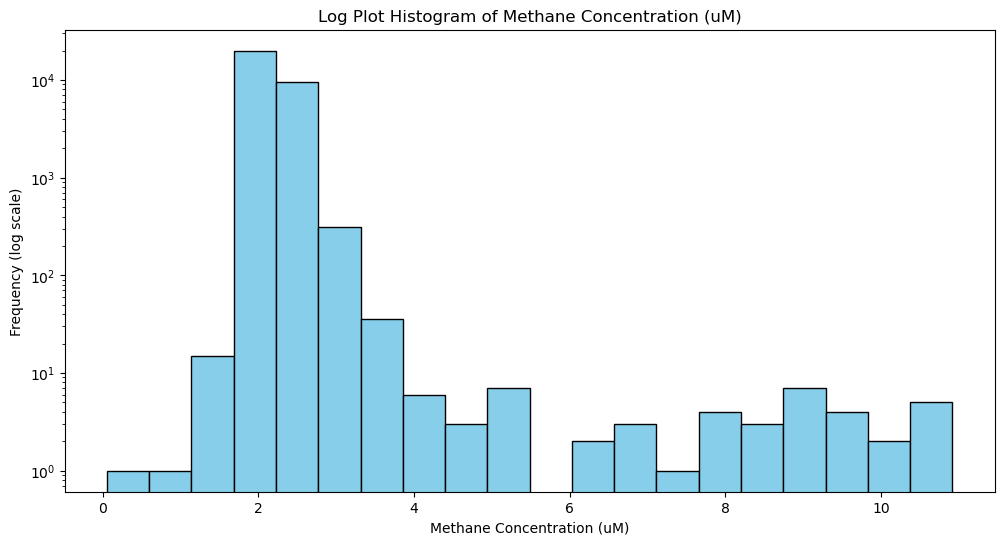

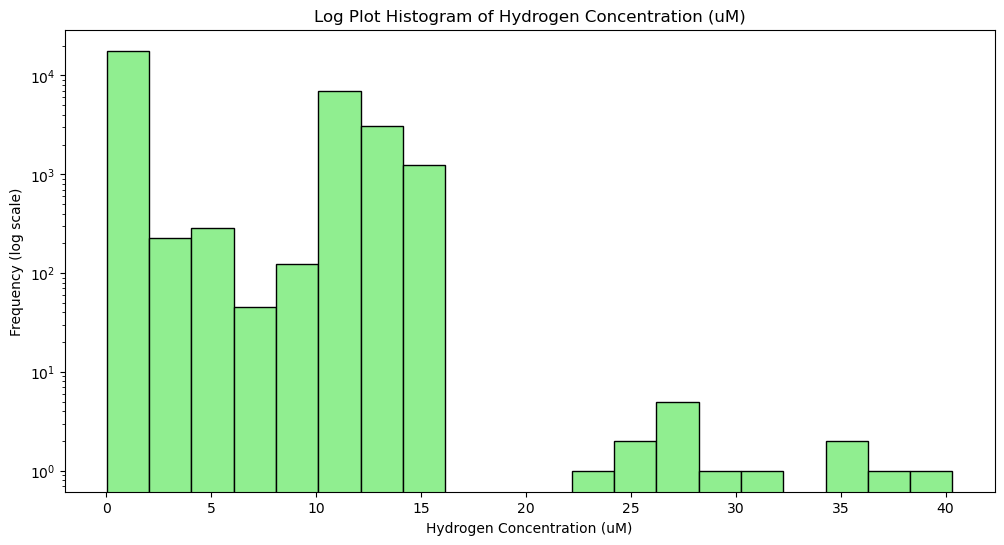

In [24]:
# Log plot histogram of Methane_Concentration_uM
plt.figure(figsize=(12, 6))
plt.hist(new_df['Methane_Concentration_uM'], bins=20, color='skyblue', edgecolor='black')
plt.yscale('log')
plt.title('Log Plot Histogram of Methane Concentration (uM)')
plt.xlabel('Methane Concentration (uM)')
plt.ylabel('Frequency (log scale)')
plt.show()

# And repeat for Hydrogen
plt.figure(figsize=(12, 6))
plt.hist(new_df['Hydrogen_Concentration_uM'], bins=20, color='lightgreen', edgecolor='black')
plt.yscale('log')
plt.title('Log Plot Histogram of Hydrogen Concentration (uM)')
plt.xlabel('Hydrogen Concentration (uM)')
plt.ylabel('Frequency (log scale)')
plt.show()

In [25]:
# Save the timestamp and methane concentration columns to a new CSV file
new_df[['Timestamp', 'Methane_Concentration_uM', 'Hydrogen_Concentration_uM']].to_csv('methane_hydrogen_concentration_2017.csv', index=False)